# Example of Making a PSF

The point-spread function (PSF) is an essential component for modeling of strongly lensed quasars, describing how the point-like quasar images are defracted by a detector. In this notebook, we provide an example of creating a PSF from stars in a science mosaic using the two methodologies currently implemented in `dolphin`:
1) `STARRED` ([GitLab](https://gitlab.com/cosmograil/starred))
2) `PSFr` ([GitHub](https://github.com/sibirrer/psfr))

Via simulated HST F814W data, [Millon et al. (2024)](https://iopscience.iop.org/article/10.3847/1538-3881/ad4da7) demonstrated that the `STARRED` PSF fitting methodology leads to order-of-magnitude reduced error over `PSFr`. As such, we recommend that new users take preference to the `STARRED` methodology, but acknowledge that an empirical comparison between the two techniques has not yet been performed on JWST data.

# Initializing the PSF class

In order to initialize the PSF class, the full science image path must be provided, ending in `.fits`. For HST data, an additional file containing the weight information must also be provided, ending in `.fits`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

from dolphin.preprocessing.psf import PSF

io_directory = "../io_directory_example"
lens_name = "lensed_quasar_3"
data_band = "F814W"
full_image_file = f"{io_directory}/full_image_{lens_name}_{data_band}.fits"
weight_image_file = f"{io_directory}/weight_image_{lens_name}_{data_band}.fits"

psf = PSF(
    io_directory=io_directory,
    lens_name=lens_name,
    data_band=data_band,
    instrument="HST",
    full_image_file=full_image_file,
    weight_image_file=weight_image_file
)

/Users/rbrady0110/micromamba/envs/dolphin/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Obtain Candidate Objects with `photutils`

To obtain a set of candidate objects from the science image, `photutils` is run. The function `psf.get_psf_candidates()` generates cutouts of the candidate objects, cutouts of their weight maps, and cutouts of the noise maps. We can adjust the threshold over the calculated background for which we want to include candidate objects using `threshold_over_background`. One can also adjust the size of the star cutout using `cutout_size`.

Found 31 candidate objects!


/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:617: RuntimeWarning: invalid value encountered in log10
  im_star = ax[i].imshow(np.log10(star_exposures[i].data), cmap="viridis")


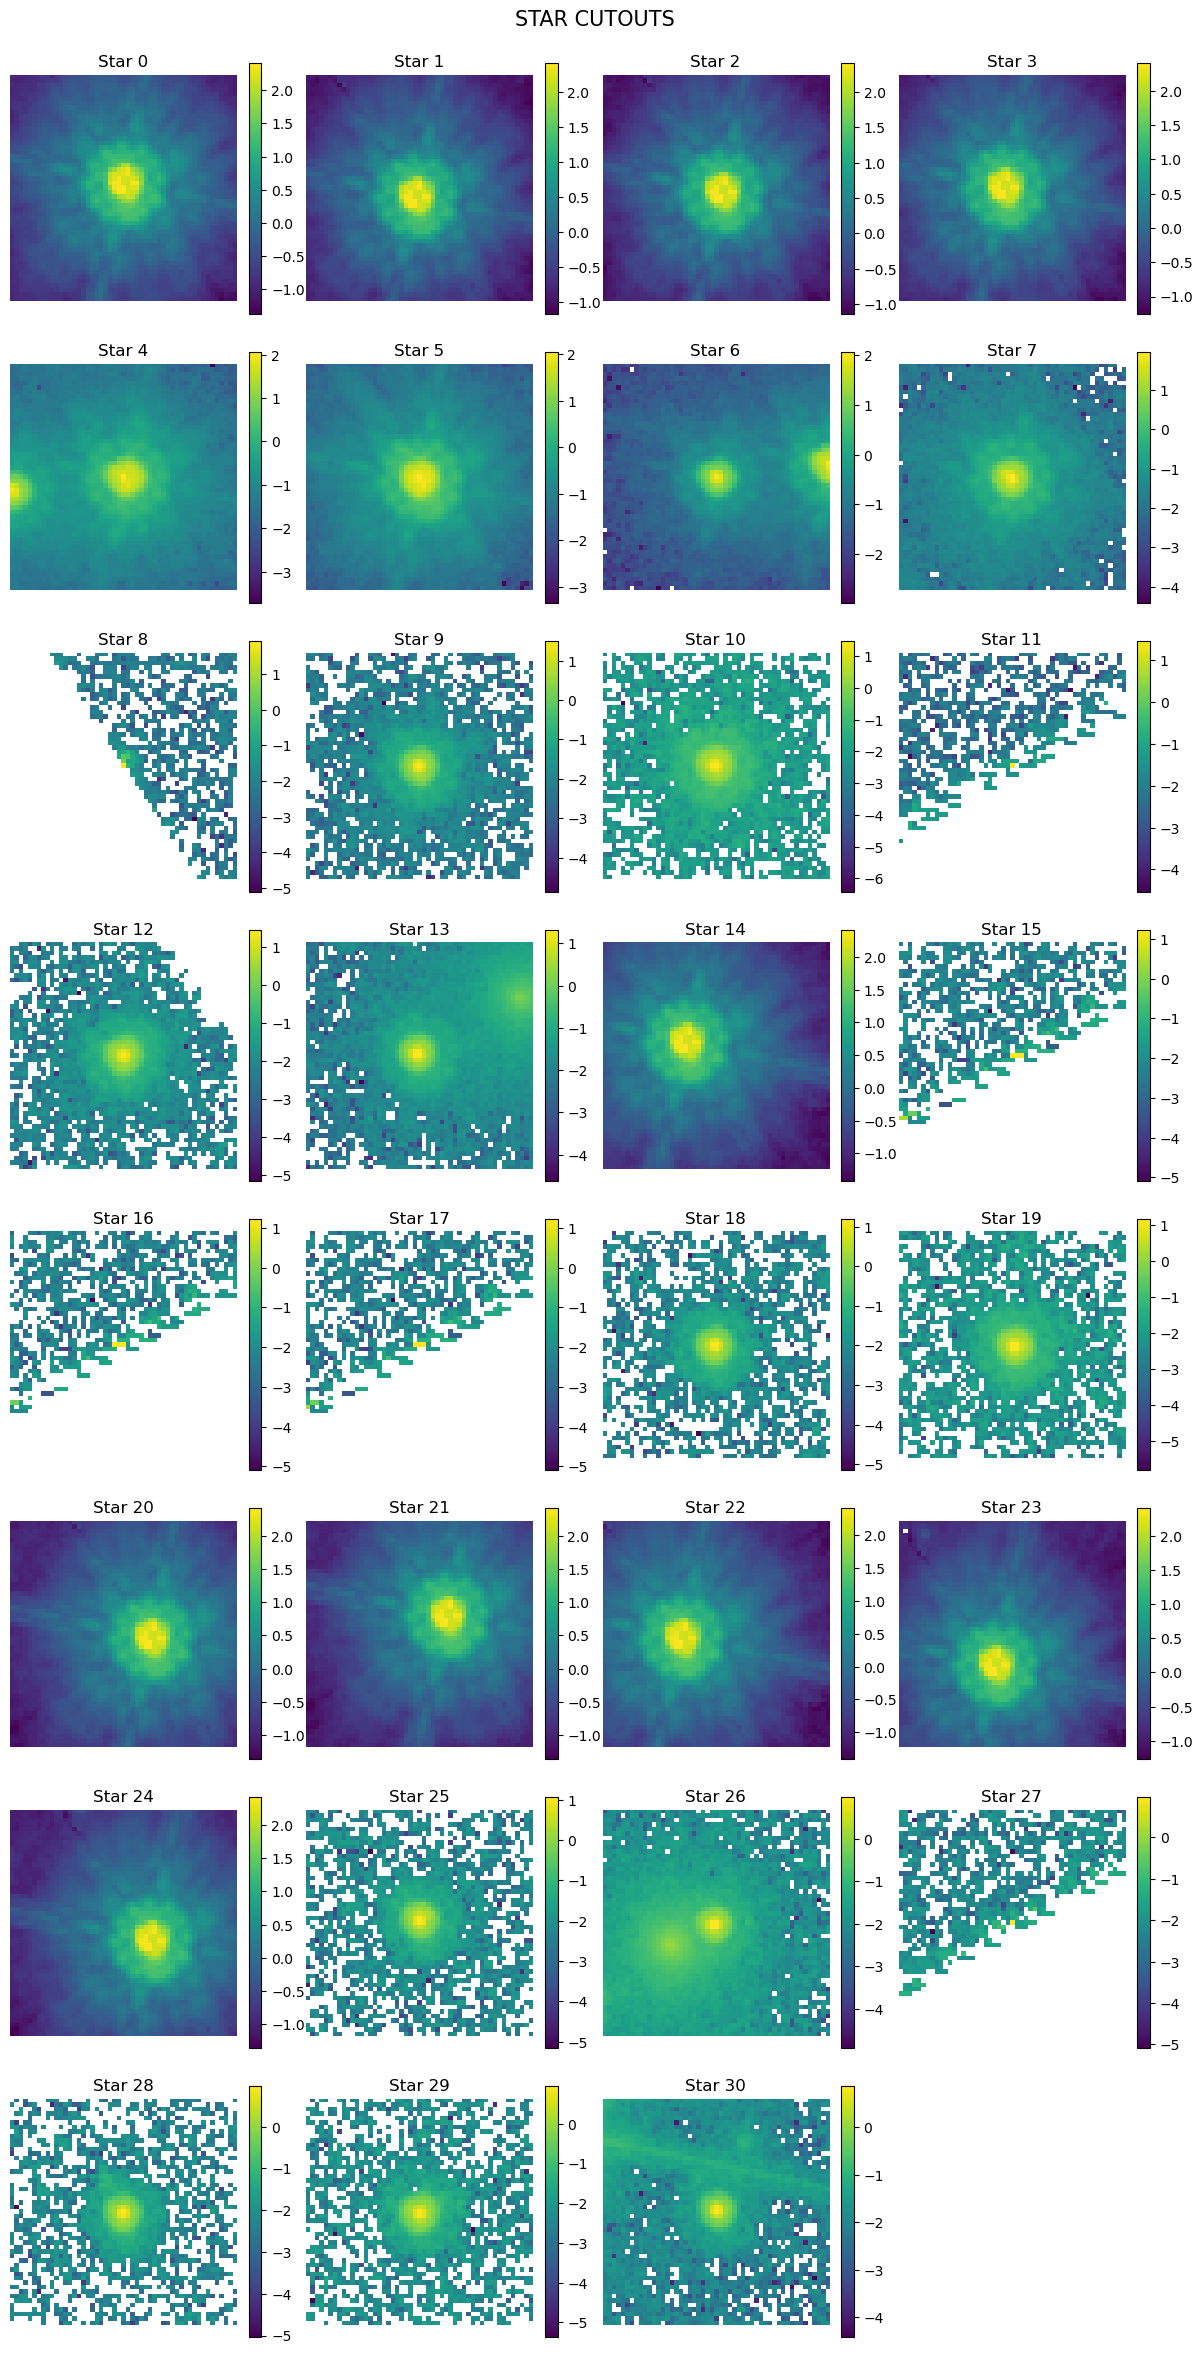

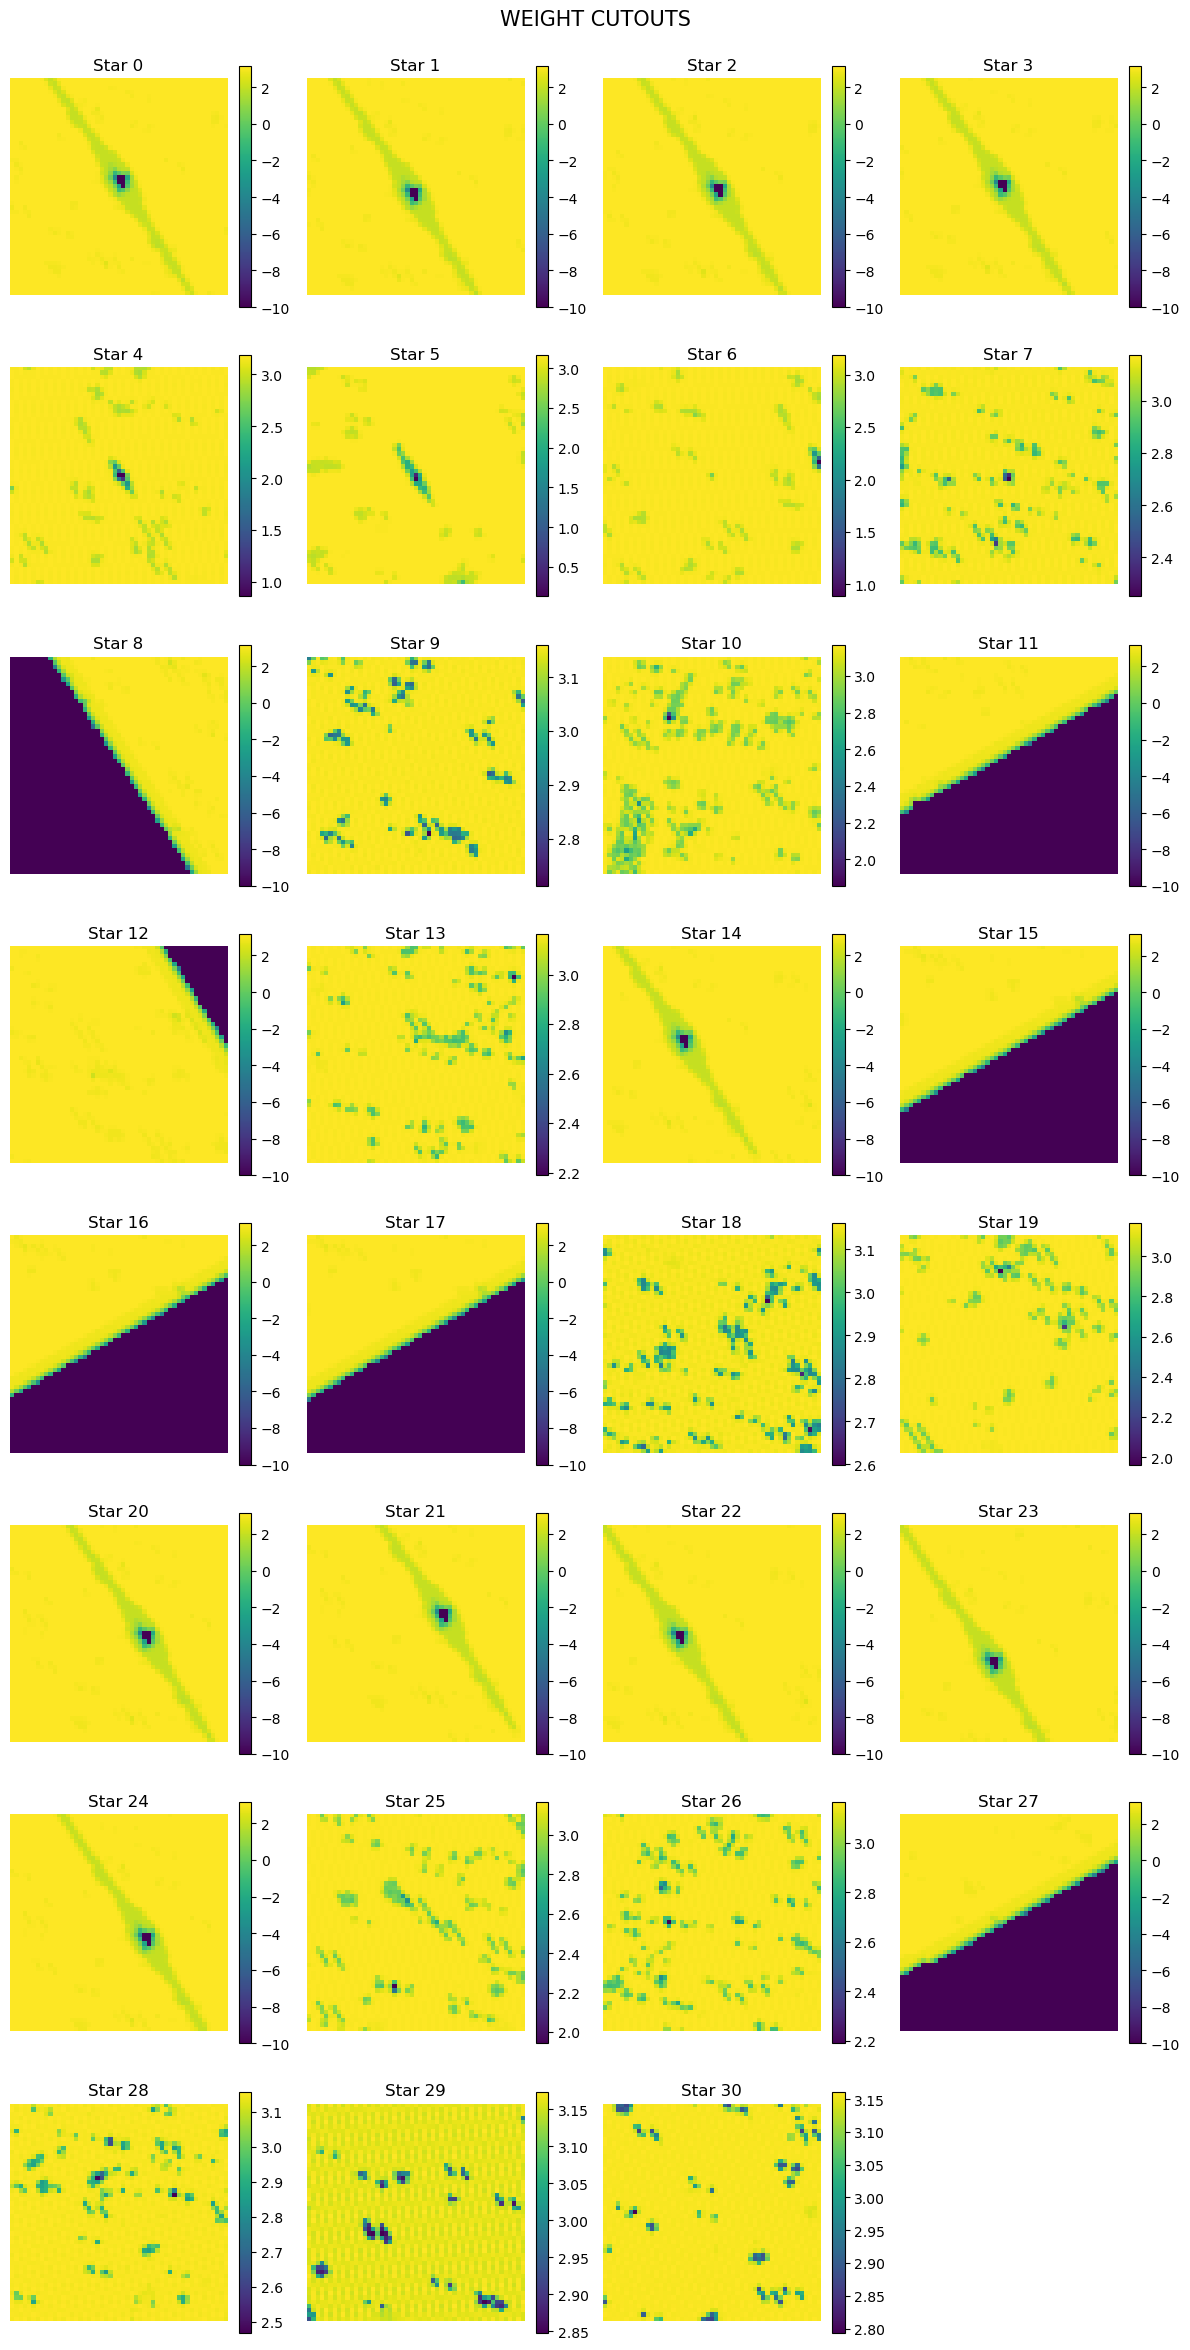

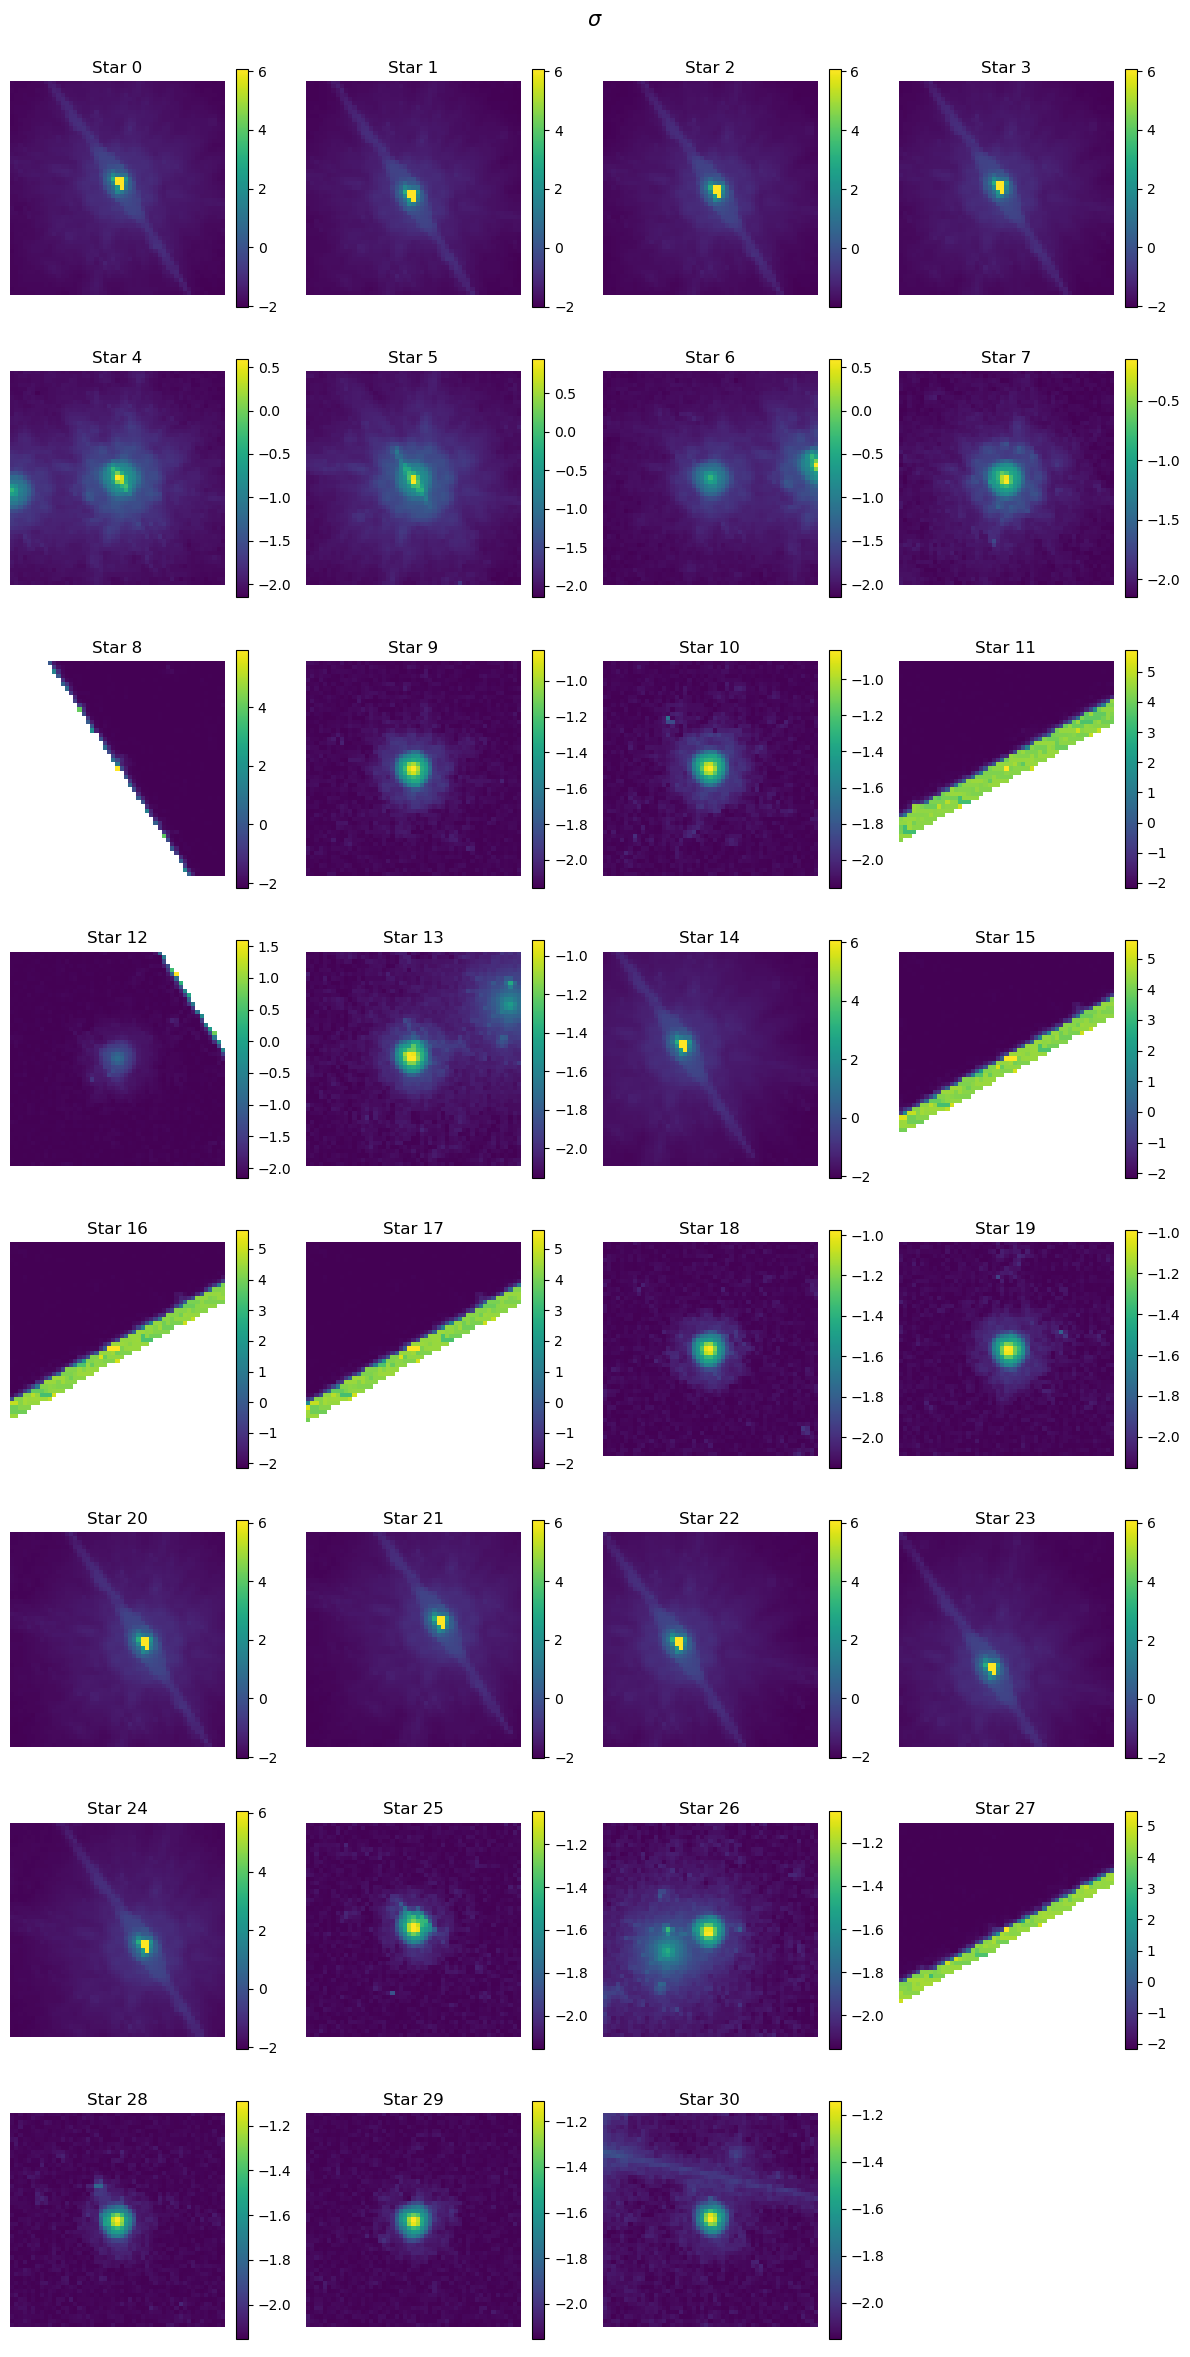

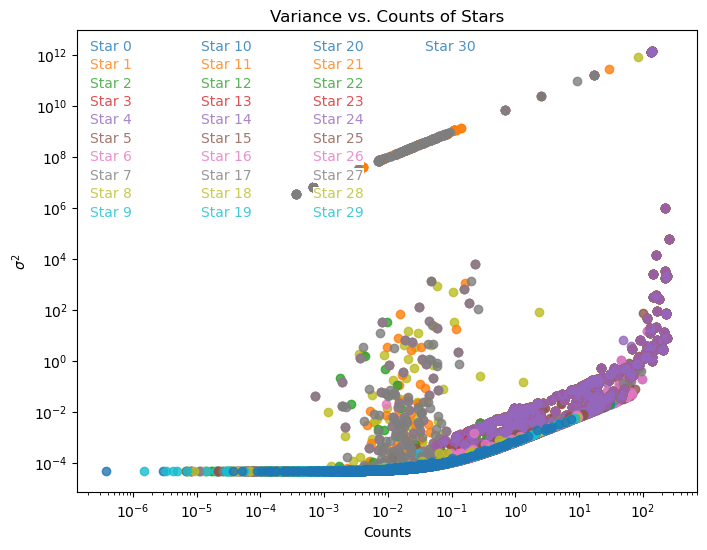

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:720: RuntimeWarning: invalid value encountered in log10
  plt_data = np.log10(data_full + 0.1)


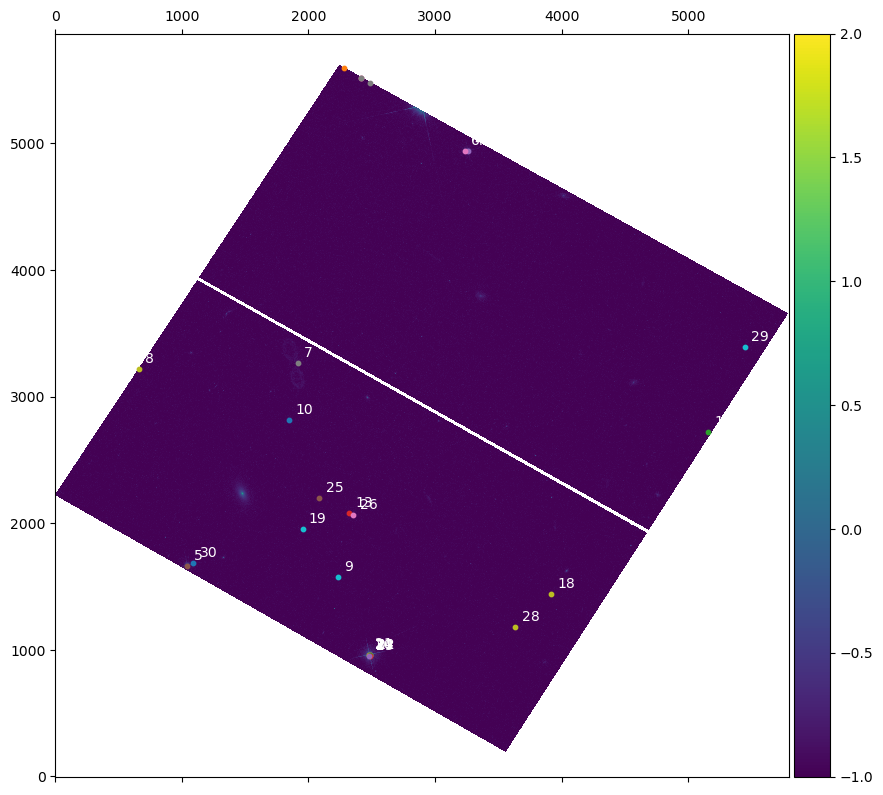

In [2]:
star_data_list, weight_data_list, noise_map_list = psf.get_psf_candidates(
    threshold_over_background=1000, cutout_size=51, save=False
)

It is clear that there are numerous stars which should not be propagated to the PSF fitting sequence. The `get_psf_canidates()` function has two distinct options on removing such bad candidate stars. Firstly, one can provide a list of integers corresponding to the cutout numbers of stars to exclude, named `exclude_specific`. The other, and in this case more economical, option is to provide a list of integers of only the stars to propagate forward, named `include_specific`. If both lists are provided, `include_specific` will take priority. 

Another diagnostic to investigate is the Variance vs. Counts of our candidate stars. For pixels dominated by background noise, the variance should approach a roughly constant floor at low count levels, corresponding to the read noise, sky background, and other additive noise sources. As the counts increase and Poisson statistics begin to dominate, the variance should scale linearly with the signal.

If desired, one can run the function with `save = True` to save the data, weight, and noise map cutouts in a `preprocessing / psf_workspace` directory located within the `data / {lens_name}` directory.

Found 4 candidate objects!


/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:617: RuntimeWarning: invalid value encountered in log10
  im_star = ax[i].imshow(np.log10(star_exposures[i].data), cmap="viridis")


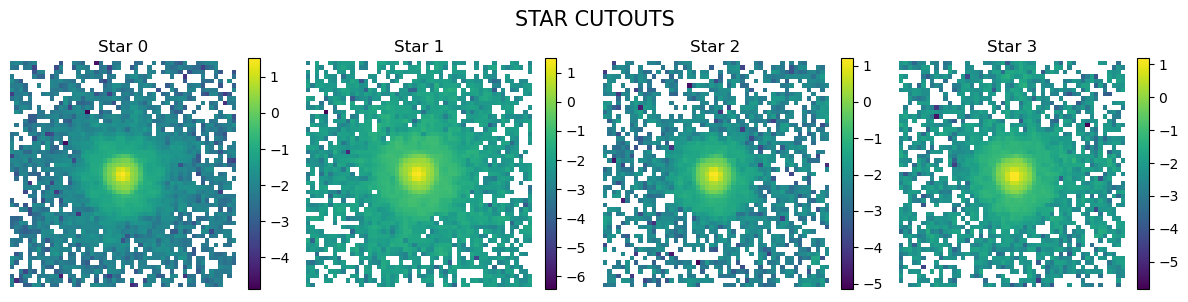

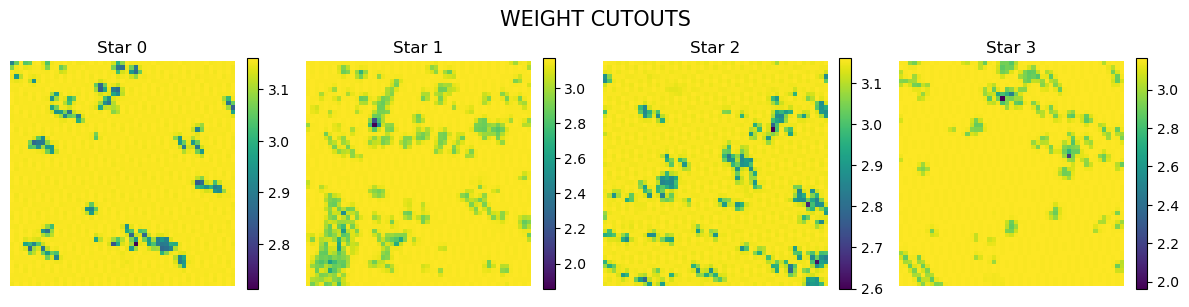

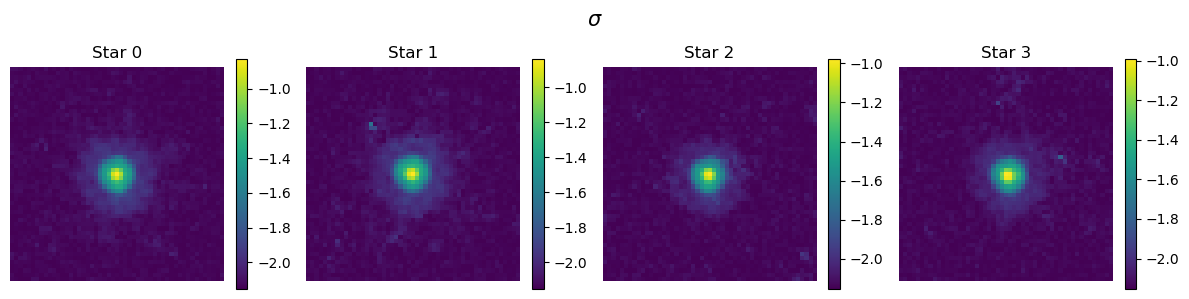

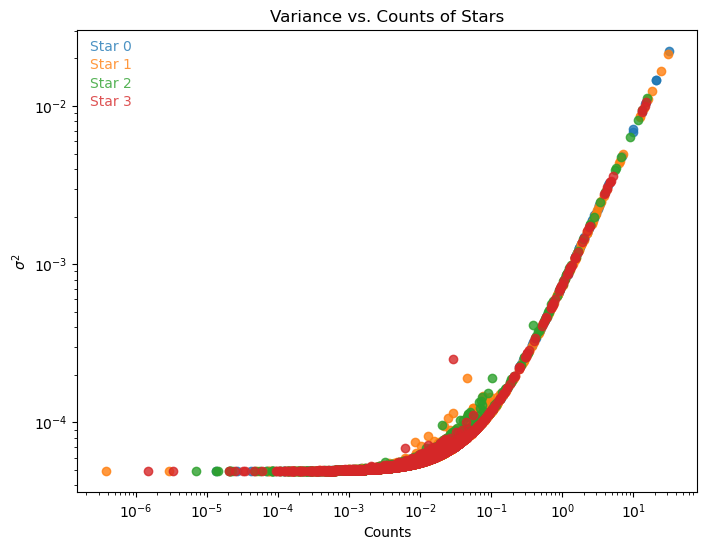

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:720: RuntimeWarning: invalid value encountered in log10
  plt_data = np.log10(data_full + 0.1)


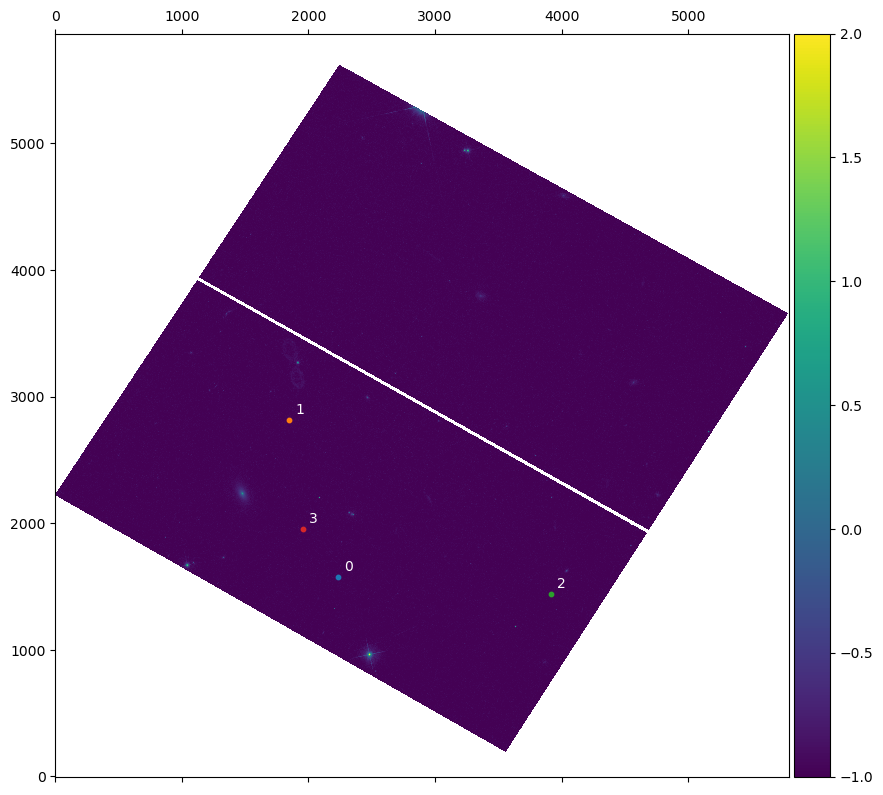

In [4]:
include_specific = [9, 10, 18, 19]

star_data_list, weight_data_list, noise_map_list = psf.get_psf_candidates(
    threshold_over_background=1000,
    cutout_size=51,
    include_specific=include_specific,
    save=True,
)

# 1) Making a PSF with `STARRED`

We can make a PSF using the `STARRED` software easily with ``psf.make_psf_starred()``. Many of the inputs correspond to those asked by `STARRED` (see their [documentation](https://cosmograil.gitlab.io/starred/) for further information). Exclusively here, there is an option to cut pixels that are below a certain threshold from the final PSF with `cut_threshold`, which is mainly used to exclude low-signal pixels at the outer edges of the PSF. Once we have determined a PSF that looks reasonable, ``save=True`` saves the PSF in an HDF5 file format which is expected by `dolphin` and is automatically put in the proper data directory.

/Users/rbrady0110/micromamba/envs/dolphin/lib/python3.14/site-packages/starred/optim/optimization.py:181: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')
/Users/rbrady0110/micromamba/envs/dolphin/lib/python3.14/site-packages/starred/utils/noise_utils.py:53: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)
optax.adabelief: 100%|██████████| 1500/1500 [00:00<00:00, 1709.46it/s]


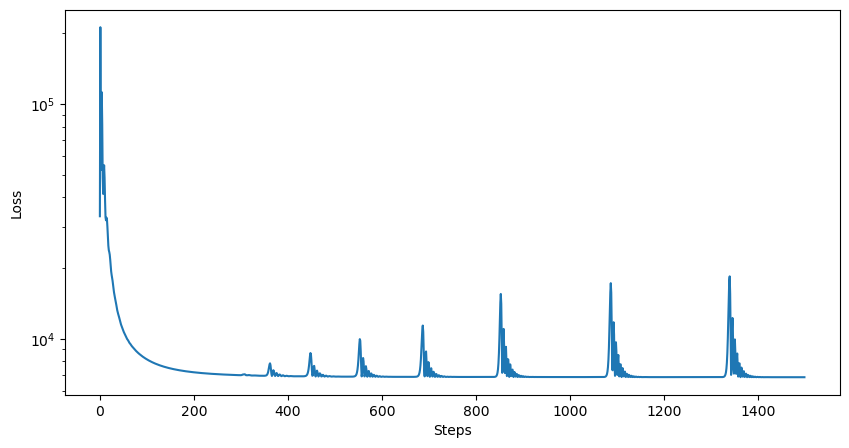

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:915: RuntimeWarning: invalid value encountered in log10
  im_psf = ax[0].imshow(np.log10(psf_guess), origin="lower", cmap="viridis")


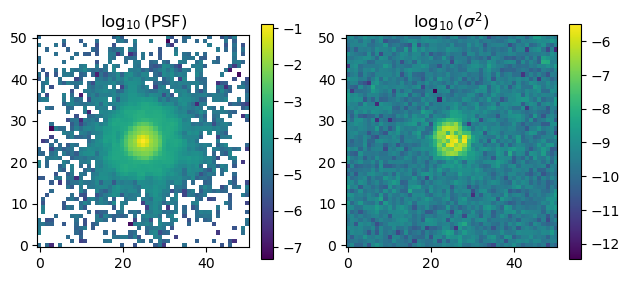

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:928: RuntimeWarning: divide by zero encountered in log10
  ax[0].imshow(np.log10(psf_cut))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:934: RuntimeWarning: divide by zero encountered in log10
  ax[1].imshow(np.log10(variance_map_cut))


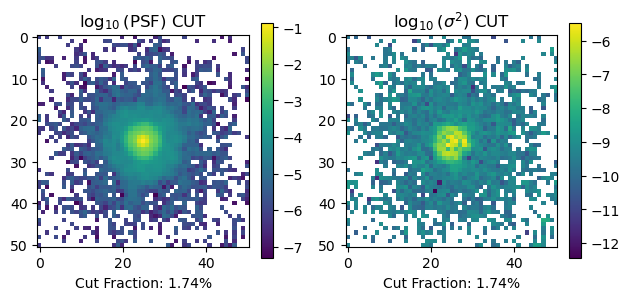

In [5]:
psf_starred, variance_map_starred = psf.make_psf_starred(
    star_data_list=star_data_list, 
    noise_map_list=noise_map_list,
    cut_threshold=1.0e-6, 
    save=True
)

# 2) Making a PSF with `PSFr`

Similarly to `STARRED`, many of the inputs for the `PSFr` branch of making a PSF are parameters that can be read about in the PSFr [documentation](https://psfr.readthedocs.io/en/latest/). The two unique `dolphin` parameters are again ``cut_threshold`` and ``save``.

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:883: RuntimeWarning: invalid value encountered in log10
  im_psf = ax[0].imshow(np.log10(psf_guess), origin="lower", cmap="viridis")
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:887: RuntimeWarning: divide by zero encountered in log10
  im_variance = ax[1].imshow(np.log10(variance_map), origin="lower")


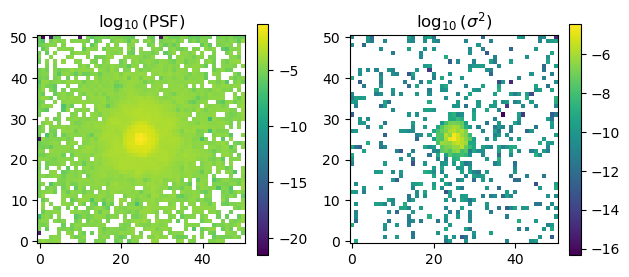

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:896: RuntimeWarning: divide by zero encountered in log10
  ax[0].imshow(np.log10(psf_cut))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:900: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 640x480 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(im_psf, ax=ax[0], fraction=0.05)
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:902: RuntimeWarning: divide by zero encountered in log10
  ax[1].imshow(np.log10(variance_map_cut))
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:905: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 640x480 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(im_variance, ax=ax[1], fraction=0.05)


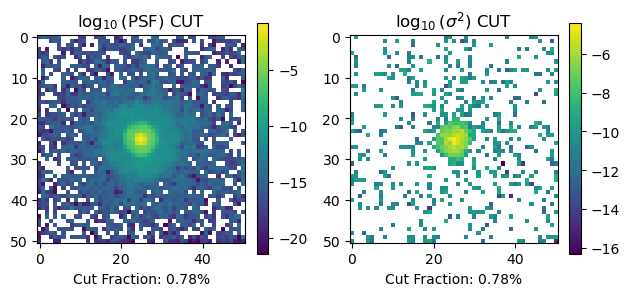

In [6]:
psf_psfr, variance_map_psfr = psf.make_psf_psfr(star_data_list=star_data_list,
                                                noise_map_list=noise_map_list,
                                                cut_threshold=1.0e-6, 
                                                save=False
                                            )

Congratulations! You have just made a PSF using both the `STARRED` and `PSFr` software. Let's see how they compare:

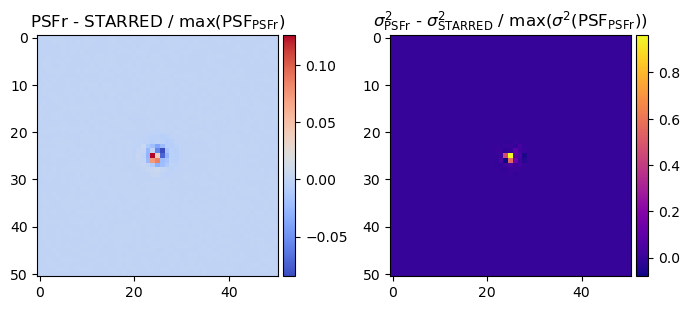

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
im1 = ax[0].imshow((psf_psfr - psf_starred) / np.max(psf_psfr), cmap="coolwarm")
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax, orientation="vertical")

im2 = ax[1].imshow(
    (variance_map_psfr - variance_map_starred) / np.max(variance_map_psfr),
    cmap="plasma",
)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, cax=cax, orientation="vertical")

ax[0].set_title(r"PSFr - STARRED / max($\text{PSF}_\text{PSFr}$)")
ax[1].set_title(
    r"$\sigma^2_{\rm PSFr}$ - $\sigma^2_{\rm STARRED}$ / max($\sigma^2(\text{PSF}_\text{PSFr}$))"
)

fig.tight_layout()

# Helper Functions:

# Loading the saved PSF and Variance Map

One can easily retrieve and plot the final saved PSF and variance map with `load_saved_psf()`:

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:960: RuntimeWarning: divide by zero encountered in log10
  im_psf = ax[0].imshow(np.log10(psf_data), origin="lower", cmap="viridis")
/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/psf.py:964: RuntimeWarning: divide by zero encountered in log10
  im_variance = ax[1].imshow(np.log10(variance_map), origin="lower")


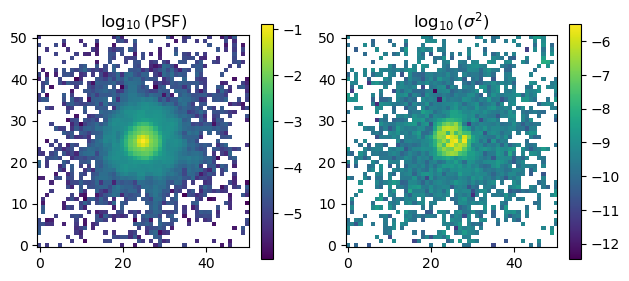

In [8]:
psf_saved, variance_map_saved = psf.load_saved_psf(plot=True)

# Loading the Saved Star Cutouts, Weights, and Noise Maps

If one ever wanted to retrieve the raw arrays containing the image cutouts, weight cutouts, and noise maps, and decided to save them during `get_psf_candidates()`, we can run the following:

In [13]:
star_data_list, weight_maps, noise_maps = (
    psf.load_psf_candidate_attributes()
)

# Quickly Re-Plotting the Saved Candidates

If one ever wanted to plot the saved candidates, we could quickly do so:

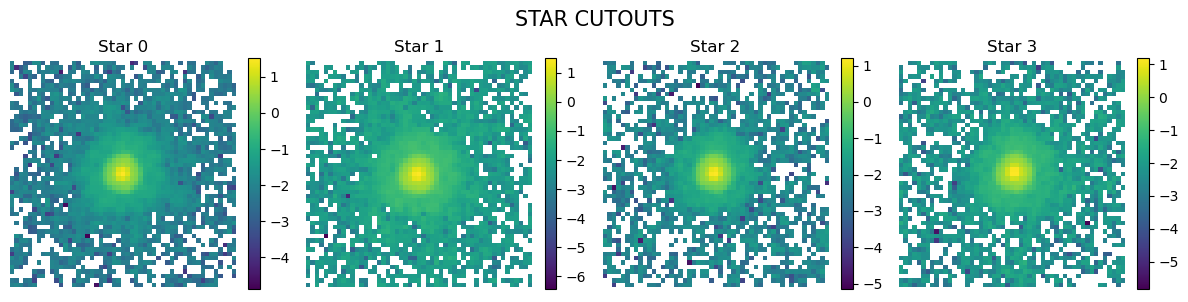

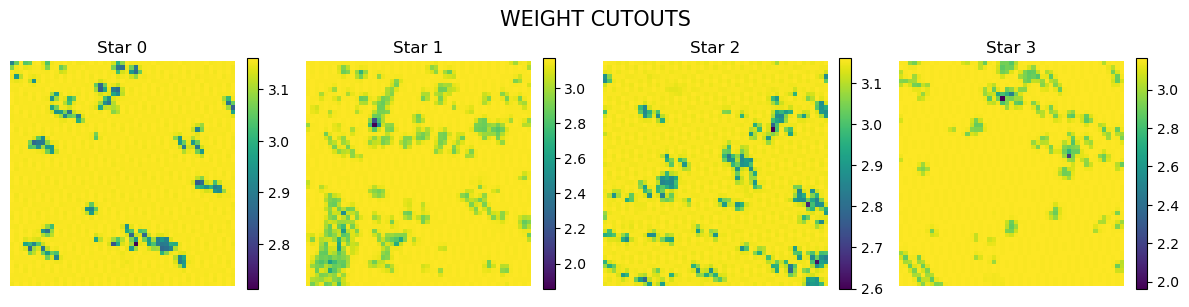

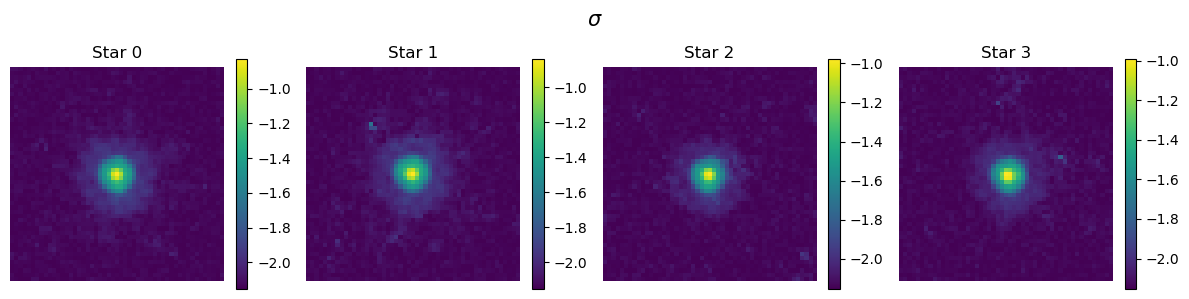

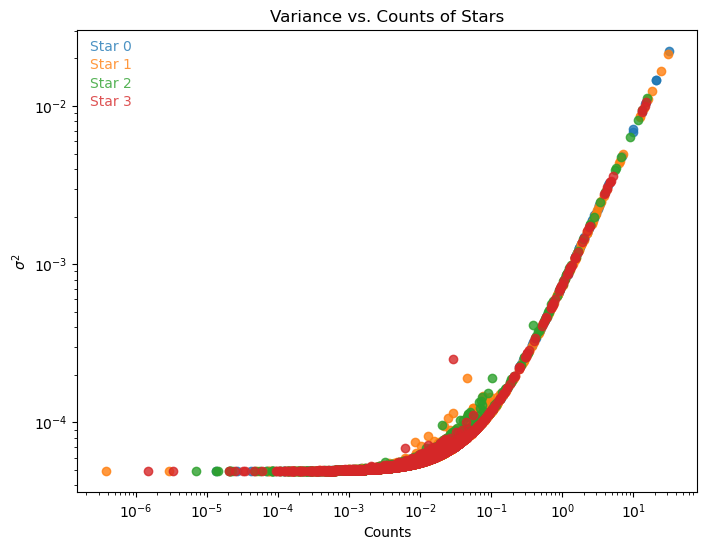

In [15]:
fig_saved = psf.plot_saved_psf_candidates()

# Pruning the PSF Workspace

For easier transfering of data between HPC's, it can be economical to remove any components that are not directly related to the lens modeling. As such, the function `clean_psf_workspace()` provides a simple mechanism to delete the individual star cutouts, weight cutouts, and noise map cutouts within the `psf_workspace / ` subdirectory (if they were chosen to be saved during `get_psf_candidates()`).

In [4]:
psf.clean_psf_workspace()

# Masking Regions

The `PSF` class also contains a helper function to make masks around specified regions of specified candidate stars. The three different mask options are `circle`, `square`, and `ellipse`. The masks can be stacked in an array of dictionaries to remove an arbitrary collection of regions from a candidate image. To invert the boolean logic of a specific mask components (for example, to change the logic from being `True` inside a region to `False` inside that same region), the key `"invert": True` must be present in that dictionary.

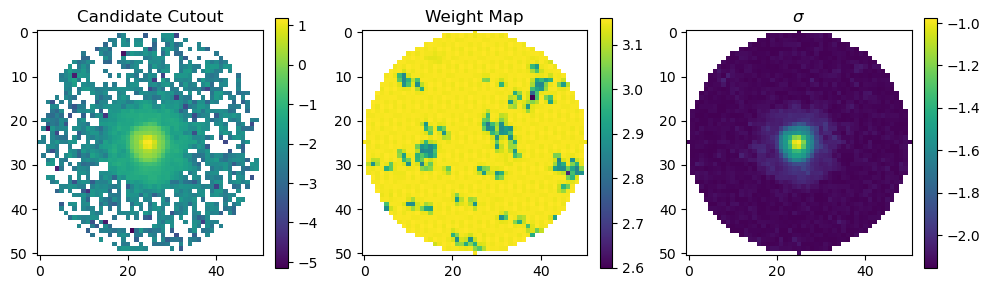

In [17]:
kwargs_mask = [{"type": "circle", "center": (25, 25), "radius": 25, "invert": False}]

mask_2 = psf.make_candidate_mask(
    star_data_list=star_data_list,
    weight_data_list=weight_data_list,
    noise_map_list=noise_map_list,
    star_num=2,
    kwargs_mask=kwargs_mask,
)

To propagate the masks into the PSF fitting sequence, the user must provide a list of boolean arrays for each star under the input `mask_list`. For the below example, the above circular mask has been applied to Star 2, while the other three stars have no masking applied.

/Users/rbrady0110/micromamba/envs/dolphin/lib/python3.14/site-packages/starred/optim/optimization.py:181: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')
optax.adabelief: 100%|██████████| 1500/1500 [00:00<00:00, 2155.92it/s]


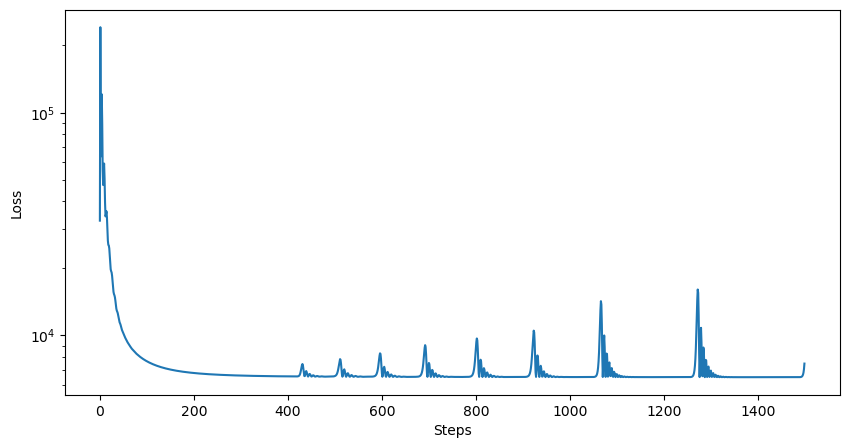

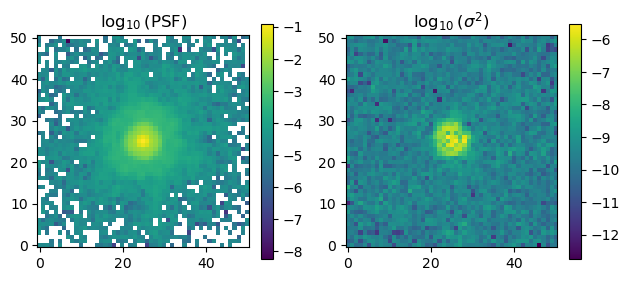

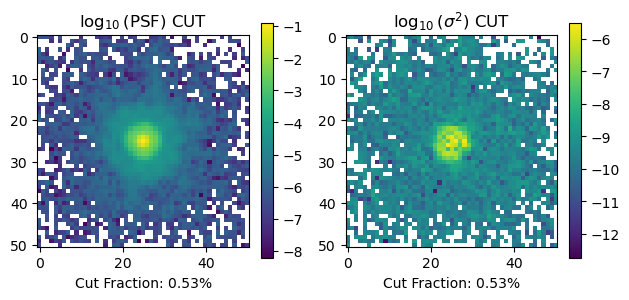

In [18]:
true_mask = np.ones(star_data_list[0].shape)
mask_list = [true_mask, true_mask, mask_2, true_mask]

psf_starred, variance_map_starred = psf.make_psf_starred(
    star_data_list=star_data_list, 
    noise_map_list=noise_map_list,
    mask_list=mask_list,
    cut_threshold=1.0e-6, 
    save=False
)